# import

In [2]:
import copy
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from shapely.affinity import affine_transform
from shapely.geometry import Point, LineString, Polygon, MultiPoint, MultiLineString, MultiPolygon, box
from geopandas import GeoSeries, GeoDataFrame
from shapely.ops import split, unary_union, polygonize
import pickle

/home/lxh/anaconda3/envs/urban3/lib/python3.9/site-packages/geopandas/_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


# Config

In [3]:
NON_BLOCK_LAND_USE = (
    'outside',
    'feasible',
    'road',
    'boundary'
)

BLOCK_LAND_USE = (
    'residential',
    'business',
    'business_h',
    'green_l',
    'residential_h',
    'school',
    'hospital_l',
    'hospital_s',
    'recreation'
)

LAND_USE = (
    NON_BLOCK_LAND_USE + BLOCK_LAND_USE)

OUTSIDE = 0
FEASIBLE = 1
ROAD = 2
BOUNDARY = 3
RESIDENTIAL = 4
BUSINESS = 5
BUSINESS_H = 6
GREEN_L = 7
RESIDENTIAL_H = 8
SCHOOL = 9
HOSPITAL_L = 10
HOSPITAL_S = 11
RECREATION = 12


LAND_USE_ID = (
    OUTSIDE,
    FEASIBLE,
    ROAD,
    BOUNDARY,
    RESIDENTIAL,
    BUSINESS,
    BUSINESS_H,
    GREEN_L,
    RESIDENTIAL_H,
    SCHOOL,
    HOSPITAL_L,
    HOSPITAL_S,
    RECREATION,
)

BLOCK_LAND_TYPE = (
    RESIDENTIAL,
    BUSINESS,
    BUSINESS_H,
    GREEN_L,
    RESIDENTIAL_H,
    SCHOOL,
    HOSPITAL_L,
    HOSPITAL_S,
    RECREATION,
)

NUM_TYPES = len(LAND_USE_ID)

LAND_USE_ID_MAP = dict(
    zip(LAND_USE, LAND_USE_ID))

LAND_USE_ID_MAP_INV = dict(
    zip(LAND_USE_ID, LAND_USE))

INTERSECTION = 13

RESIDENTIAL_ID = (
    RESIDENTIAL,
    RESIDENTIAL_H
)

PUBLIC_SERVICES_ID = (
    BUSINESS,
    BUSINESS_H,
    SCHOOL,
    (HOSPITAL_L, HOSPITAL_S),
    RECREATION
)

PUBLIC_SERVICES = (
    'shopping',
    'working',
    'education',
    'medical care',
    'entertainment'
)

GREEN_ID = (
    GREEN_L,
    RECREATION
)
GREEN_AREA_THRESHOLD = 2000

TYPE_COLOR_MAP = {
    'boundary': 'lightgreen',
    'business': '#e6005c',   # pink
    'feasible': 'white',
    'green_l': '#00ff00',
    'hospital_l': '#ff7f7e',    # light red
    'hospital_s': 'darkred',
    'business_h': '#ff0000',    # red
    'outside': 'black',
    'residential': '#ffff2d',  # yellow
    'residential_h': '#ffd380',   # light yellow
    'road': '#a3a3a3',      # grey
    'school': '#ff85c9',   # light pink
    'recreation': '#acffcf',   # light blue
}

# read data

In [3]:
gdf_block = gpd.read_file('Block.shp')
gdf_block.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Id        19 non-null     int64   
 1   Keep      14 non-null     float64 
 2   geometry  19 non-null     geometry
dtypes: float64(1), geometry(1), int64(1)
memory usage: 584.0 bytes


In [5]:
gdf_land = gpd.read_file('Polygon.shp')
gdf_land.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Id        12 non-null     int64   
 1   Type      12 non-null     int64   
 2   Keep      12 non-null     int64   
 3   geometry  12 non-null     geometry
dtypes: geometry(1), int64(3)
memory usage: 512.0 bytes


In [6]:
gdf_land_all = pd.concat([gdf_land,gdf_block])

In [120]:
gdf_land.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Id        12 non-null     int64   
 1   Type      12 non-null     int64   
 2   Keep      12 non-null     int64   
 3   geometry  12 non-null     geometry
dtypes: geometry(1), int64(3)
memory usage: 512.0 bytes


In [123]:
for idx, row in gdf_land.iterrows():
    gdf_land.loc[idx, 'id'] = idx
    gdf_land.loc[idx, 'existence'] = 'true'

In [55]:
gdf_land['properties'] = gdf_land.apply(lambda x: {
    'id': x.name,
    'type': 1,
    'existence': True
}, axis=1)

In [129]:
gdf_land['type'] = gdf_land['Type'].astype(int)

In [124]:
gdf_land['id'] = gdf_land['id'].astype(int)

In [127]:
gdf_land = gpd.GeoDataFrame(gdf_land, geometry='geometry')

In [5]:
gdf_hz = gpd.read_file('hz.geojson', driver='GeoJSON')

In [6]:
gdf_scaled=gpd.read_file('hz_scaled.geojson')

In [7]:
gdf_scaled.crs = None

In [44]:
from shapely.wkt import loads, dumps

def round_coords(geom):
    # Parse the geometry and round coordinates to 1 decimal place
    return loads(dumps(geom, rounding_precision=0))

# Read your GeoDataFrame (assuming you have it saved somewhere)
# gdf_scaled = gpd.read_file('your_file.geojson')  # Uncomment and modify path as needed

# Apply rounding to geometry column
gdf_scaled['geometry'] = gdf_scaled['geometry'].apply(round_coords)


<Axes: >

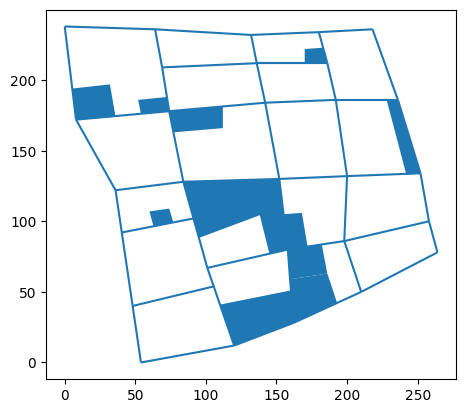

In [46]:
gdf_scaled.plot()

In [ ]:
gdf_scaled['geometry'] 

In [48]:
gdf_scaled.to_file('hz_scaled.geojson', driver='GeoJSON')

In [21]:
gdf_scaled.crs

In [12]:
import folium

# 创建地图对象
m = folium.Map(location=[gdf_hz.geometry.centroid.y.mean(), 
                        gdf_hz.geometry.centroid.x.mean()],
               zoom_start=12)

# 添加地块多边形
folium.GeoJson(gdf_hz).add_to(m)

# 显示地图
m

/tmp/ipykernel_563864/1602305686.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  m = folium.Map(location=[gdf_hz.geometry.centroid.y.mean(),
/tmp/ipykernel_563864/1602305686.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_hz.geometry.centroid.x.mean()],


# translate, rescale, obtain intersections

In [4]:
def translate_and_rescale(gdf):
    # Get the minimum x and y values from total_bounds
    x_min, y_min, x_max, y_max = gdf.total_bounds
    
    # Calculate the translation values
    x_translation = -x_min
    y_translation = -y_min
    
    # Apply the translation to the GeoDataFrame
    gdf['geometry'] = gdf.translate(xoff=x_translation, yoff=y_translation)
    
    scaling_factor = 0.1  # Scale down by a factor of 10
    
    # Create the scaling matrix
    scaling_matrix = [scaling_factor, 0, 0, scaling_factor, 0, 0]
    
    # Apply the scaling transformation to the GeoDataFrame
    gdf['geometry'] = gdf['geometry'].apply(lambda geom: affine_transform(geom, scaling_matrix))

    return gdf

In [9]:

gdf_scaled.head()

,id,type,existence,geometry
0,0,2,true,"LINESTRING (0.000 238.000, 64.000 236.000)"
1,1,2,true,"LINESTRING (64.000 236.000, 132.000 232.000)"
2,2,2,true,"LINESTRING (132.000 232.000, 180.000 234.000)"
3,3,2,true,"LINESTRING (180.000 234.000, 218.000 236.000)"
4,4,2,true,"LINESTRING (136.000 212.000, 186.000 212.000)"


In [17]:
import geopandas as gpd
import matplotlib.pyplot as plt
colors = {
    1: (172, 255, 207),    # 广场用地	G3
    2: (0, 255, 0),        # 公园绿地 G
    3: (255, 211, 128),    # 居住用地（高层） Rh
    4: (255, 255, 45),     # 居住用地（多层） Rl
    5: (230, 0, 92),       # 商业服务业用地（低容积率） Bl
    6: (255, 0, 0),        # 商业服务业（高容积率） Bh
    7: (255, 127, 126),    # 医疗卫生用地 A5
    8: (255, 127, 0),      # 文化用地 A2
    9: (255, 133, 201),    # 教育用地 A3
    10: (0, 99, 128),      # 公共设施用地 U1
    11: (163, 163, 163),    # 道路用地
    12: (0, 0, 0),         # 矩形
    13: (255, 255, 255)    # 点
}

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def plot_gdf_with_rgb(gdf, rgb_colors=None, figsize=(10, 10), alpha=0.7, labels=None):
    """
    Plot GeoDataFrame with RGB colors and legend
    
    Args:
        gdf: GeoDataFrame to plot
        rgb_colors: Dict of type_id: (r,g,b) where r,g,b are 0-255
        figsize: Tuple for figure size
        alpha: Float for transparency
        labels: Dict of type_id: label_name for legend. If None, type_id will be used as label
    """
    if rgb_colors is None:
        # Default colors as example
        rgb_colors = {
            1: (255, 99, 71),   # Tomato red
            2: (70, 130, 180),  # Steel blue
            13: (34, 139, 34)   # Forest green
        }
    
    # Convert RGB (0-255) to matplotlib format (0-1)
    color_map = {
        k: (r/255, g/255, b/255) 
        for k, (r,g,b) in rgb_colors.items()
    }
    
    if labels is None:
        labels = {k: f'Type {k}' for k in rgb_colors.keys()}
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create legend elements
    legend_elements = []
    
    # Plot each type with its color
    for type_id, color in color_map.items():
        mask = gdf['type'] == type_id
        if mask.any():
            gdf[mask].plot(
                ax=ax,
                color=color,
                alpha=alpha
            )
            # Create patch for legend
            legend_elements.append(
                Patch(facecolor=color, 
                      alpha=alpha,
                      label=labels[type_id])
            )
    
    # Add legend with custom patches
    ax.legend(handles=legend_elements,bbox_to_anchor=(1.8, 1))
    
    
    # Adjust plot
    plt.axis('equal')
    plt.grid(True)
    plt.show()
    
    return fig, ax
#plot_gdf_with_rgb(gdf_combined,rgb_colors=colors)

In [ ]:
plot_gdf_with_rgb(gdf_scaled, rgb_colors=colors)

In [27]:
gdf_simplized =gpd.read_file('hz_simplified.geojson')


In [ ]:
gdf_simplized.crs = None
plot_gdf_with_rgb(gdf_simplized, rgb_colors=colors)

In [28]:
gdf_rescaled = translate_and_rescale(gdf_simplized)
gdf_rescaled

,id,type,existence,geometry
0,0,2,True,"LINESTRING (0.00000 2380.00000, 640.00000 2360..."
1,1,2,True,"LINESTRING (640.00000 2360.00000, 1320.00000 2..."
2,2,2,True,"LINESTRING (1320.00000 2320.00000, 1800.00000 ..."
3,3,2,True,"LINESTRING (1800.00000 2340.00000, 2180.00000 ..."
4,4,2,True,"LINESTRING (1360.00000 2120.00000, 1860.00000 ..."
...,...,...,...,...
93,93,6,True,"POLYGON ((1010.00000 670.00000, 1580.00000 800..."
94,94,8,True,"POLYGON ((1580.00000 800.00000, 1980.00000 860..."
95,95,1,True,"POLYGON ((1980.00000 860.00000, 2580.00000 100..."
96,96,1,True,"POLYGON ((360.00000 1220.00000, 840.00000 1280..."


In [29]:
gdf_rescaled.to_file('hz_rescaled.geojson', driver='GeoJSON')

In [30]:
gdf_rescaled.crs = None

In [32]:
d=dict()
d['gdf'] = gdf_rescaled
with open('./init_plan_hz.pickle', 'wb') as f:
    pickle.dump(d, f)


In [33]:
d = pickle.load(open('./init_plan_hz.pickle', 'rb'))
d

{'gdf':     id  type  existence                                           geometry
 0    0     2       True  LINESTRING (0.00000 2380.00000, 640.00000 2360...
 1    1     2       True  LINESTRING (640.00000 2360.00000, 1320.00000 2...
 2    2     2       True  LINESTRING (1320.00000 2320.00000, 1800.00000 ...
 3    3     2       True  LINESTRING (1800.00000 2340.00000, 2180.00000 ...
 4    4     2       True  LINESTRING (1360.00000 2120.00000, 1860.00000 ...
 ..  ..   ...        ...                                                ...
 93  93     6       True  POLYGON ((1010.00000 670.00000, 1580.00000 800...
 94  94     8       True  POLYGON ((1580.00000 800.00000, 1980.00000 860...
 95  95     1       True  POLYGON ((1980.00000 860.00000, 2580.00000 100...
 96  96     1       True  POLYGON ((360.00000 1220.00000, 840.00000 1280...
 97  97     1       True  POLYGON ((950.00000 890.00000, 1540.00000 1110...
 
 [98 rows x 4 columns]}

In [50]:

#gdf_combined = translate_and_rescale(gdf_combined)
gdf_road = gdf_scaled[gdf_scaled['type']==2].copy()
#gdf_main_road = gdf_combined[gdf_combined['type']=='main_road'].copy()

In [ ]:
gdf_road

In [52]:
def explode_lines(gdf_road):
    # Create or load the GeoDataFrame gdf_road
    # For this example, let's assume you have a GeoDataFrame named gdf_road
    
    # Define a tolerance value for simplification (adjust as needed)
    tolerance = 0.1  # You can adjust this value based on your dataset and needs
    
    # Apply the simplify operation to the 'geometry' column
    gdf_road['geometry'] = gdf_road['geometry'].apply(lambda geom: geom.simplify(tolerance, preserve_topology=True) if geom.geom_type == 'LineString' else geom)
    
    
    # Define a function to extract coordinates from LineString and convert to Points
    def extract_coordinates_to_points(line):
        return [Point(coord) for coord in line.coords]
    
    # Apply the function to create a new 'points' column
    gdf_road['points'] = gdf_road['geometry'].apply(extract_coordinates_to_points)
    
    # Explode the 'points' column to create a new GeoDataFrame with points
    gdf_points = gdf_road.explode('points')
    
    # Merge LineString and Point geometries into a single 'geometry' column
    gdf_points['geometry'] = gdf_points['points']
    gdf_points = gdf_points.drop('points', axis=1)
    
    # Create a set to store unique integer nodes
    unique_nodes = set()
    
    # Function to approximate coordinates of a point to integers
    def approximate_to_integers(point):
        return Point(int(point.x), int(point.y))
    
    # Iterate through the 'geometry' column and add unique integer nodes to the set
    for geom in gdf_points['geometry']:
        if geom.geom_type == 'Point':
            integer_node = approximate_to_integers(geom)
            unique_nodes.add(integer_node)
    
    # Create a GeoDataFrame from the set of unique integer nodes
    simplified_gdf_points = gpd.GeoDataFrame(geometry=list(unique_nodes), crs=gdf_points.crs)
    
    gdf_road = gdf_road.drop('points', axis=1)
    
    # Combine the original GeoDataFrame 'gdf_road' with 'gdf_points'
    gdf = pd.concat([gdf_road, simplified_gdf_points], ignore_index=True)
    
    # Now, add the 'x' and 'y' columns
    gdf['x'] = gdf['geometry'].apply(lambda geom: geom.x if geom.geom_type == 'Point' else None)
    gdf['y'] = gdf['geometry'].apply(lambda geom: geom.y if geom.geom_type == 'Point' else None)
    return gdf

In [53]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import numpy as np

def explode_lines_for_points(gdf_road):
    # Define a tolerance value for simplification
    tolerance = 0.1
    
    # Apply the simplify operation
    gdf_road['geometry'] = gdf_road['geometry'].apply(
        lambda geom: geom.simplify(tolerance, preserve_topology=True) 
        if geom.geom_type == 'LineString' else geom
    )
    
    # Extract coordinates from LineString and convert to Points
    def extract_coordinates_to_points(line):
        return [Point(coord) for coord in line.coords]
    
    gdf_road['points'] = gdf_road['geometry'].apply(extract_coordinates_to_points)
    gdf_points = gdf_road.explode('points')
    gdf_points['geometry'] = gdf_points['points']
    gdf_points = gdf_points.drop('points', axis=1)
    
    # Instead of using a set, store coordinates in arrays
    coords = np.array([[int(point.x), int(point.y)] 
                      for point in gdf_points['geometry'] 
                      if point.geom_type == 'Point'])
    
    # Get unique coordinates
    unique_coords = np.unique(coords, axis=0)
    
    # Create points from unique coordinates
    unique_points = [Point(x, y) for x, y in unique_coords]
    
    # Create GeoDataFrame from unique points
    simplified_gdf_points = gpd.GeoDataFrame(
        geometry=unique_points, 
        crs=gdf_points.crs
    )
    
    gdf_road = gdf_road.drop('points', axis=1)
    
    # Combine GeoDataFrames
    gdf = pd.concat([gdf_road, simplified_gdf_points], ignore_index=True)
    
    # Add x and y columns
    gdf['x'] = gdf['geometry'].apply(lambda geom: geom.x if geom.geom_type == 'Point' else None)
    gdf['y'] = gdf['geometry'].apply(lambda geom: geom.y if geom.geom_type == 'Point' else None)
    
    return gdf

In [54]:
#gdf_main_road=gdf_land
gdf_road_exploded = explode_lines_for_points(gdf_road)

In [59]:
gdf_road_exploded.drop(columns=['x','y'],inplace=True)

In [61]:
gdf_points=gdf_road_exploded[gdf_road_exploded['type']!=2]
gdf_points['type']=13
gdf_points['existence']='true'

/home/lxh/anaconda3/envs/urban3/lib/python3.9/site-packages/geopandas/geodataframe.py:1472: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [64]:
gdf_points

,id,type,existence,geometry
47,NaN,13,true,POINT (0.000 238.000)
48,NaN,13,true,POINT (8.000 172.000)
49,NaN,13,true,POINT (36.000 122.000)
50,NaN,13,true,POINT (40.000 92.000)
51,NaN,13,true,POINT (48.000 40.000)
52,NaN,13,true,POINT (54.000 0.000)
53,NaN,13,true,POINT (64.000 236.000)
54,NaN,13,true,POINT (69.000 209.000)
55,NaN,13,true,POINT (74.000 178.000)
56,NaN,13,true,POINT (84.000 128.000)


In [74]:
gdf_poly=gdf_scaled[gdf_scaled['type']!=2]

In [75]:
gdf_poly.head()

,id,type,existence,geometry
47,0,6,true,"POLYGON ((110.000 41.000, 160.000 51.000, 162...."
48,1,7,true,"POLYGON ((228.000 186.000, 236.000 186.000, 25..."
49,2,7,true,"POLYGON ((72.000 188.000, 74.000 178.000, 54.0..."
50,3,9,true,"POLYGON ((183.000 223.000, 186.000 212.000, 17..."
51,4,8,true,"POLYGON ((160.000 59.000, 186.000 63.000, 193...."


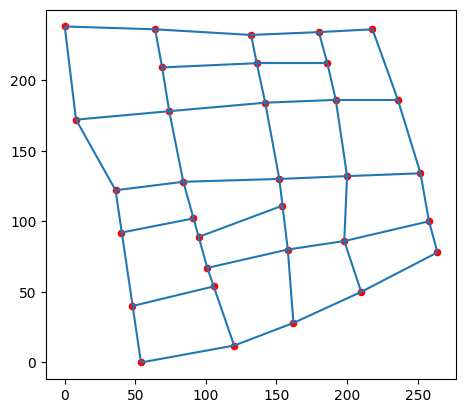

In [71]:
import geopandas as gpd
import matplotlib.pyplot as plt
gdf_temp = gdf_road_exploded[gdf_road_exploded['type'] == 2]
ax = gdf_temp.plot()
ax = gdf_points.plot(ax=ax, color='red', markersize=20)

In [37]:
gdf_rescale = gpd.read_file('hz_rescaled.geojson')
gdf_rescale

,id,type,existence,geometry
0,0,2,True,"LINESTRING (0.00000 2380.00000, 640.00000 2360..."
1,1,2,True,"LINESTRING (640.00000 2360.00000, 1320.00000 2..."
2,2,2,True,"LINESTRING (1320.00000 2320.00000, 1800.00000 ..."
3,3,2,True,"LINESTRING (1800.00000 2340.00000, 2180.00000 ..."
4,4,2,True,"LINESTRING (1360.00000 2120.00000, 1860.00000 ..."
...,...,...,...,...
93,93,6,True,"POLYGON ((1010.00000 670.00000, 1580.00000 800..."
94,94,8,True,"POLYGON ((1580.00000 800.00000, 1980.00000 860..."
95,95,1,True,"POLYGON ((1980.00000 860.00000, 2580.00000 100..."
96,96,1,True,"POLYGON ((360.00000 1220.00000, 840.00000 1280..."


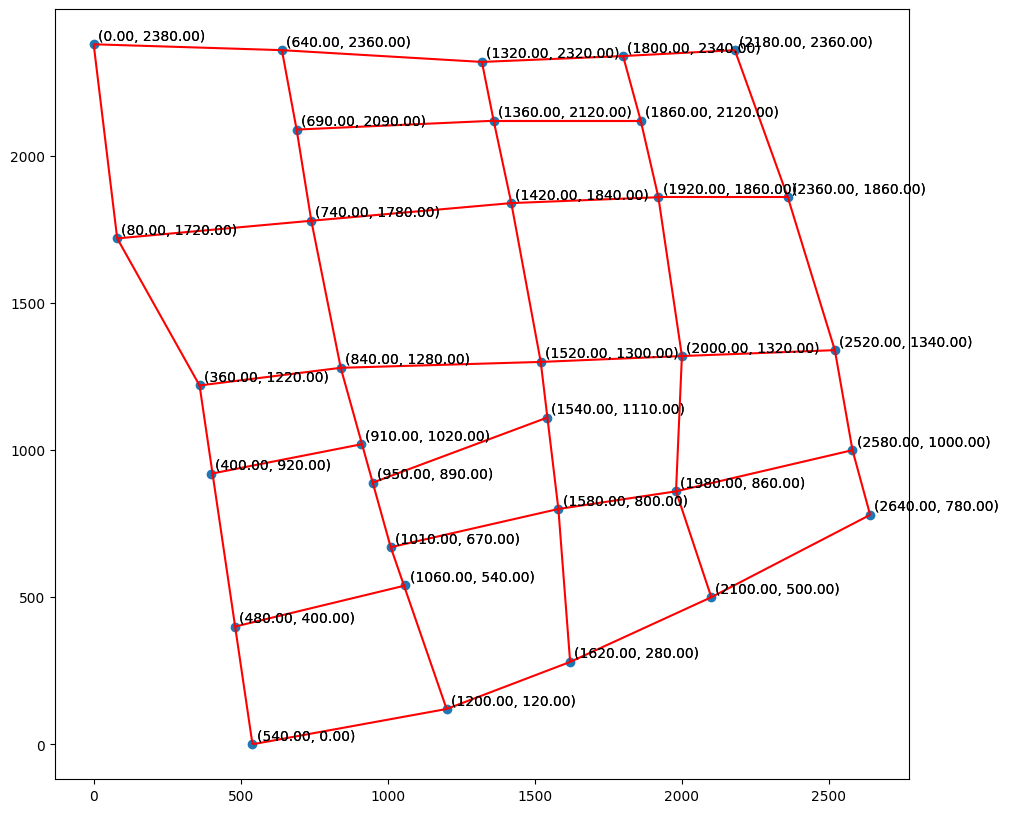

In [48]:
import geopandas as gpd
import matplotlib.pyplot as plt

gdf_temp = gdf_rescale[gdf_rescale['type'] == 13]
gdf_temp.crs = None

ax = gdf_temp.plot(figsize=(12, 10))

ax = gdf_rescale[gdf_rescale['type']==2].plot(ax=ax, color='red', markersize=20)
for idx, row in gdf_temp.iterrows():
    # 获取起点坐标
    #print(row)
    start_point = row.geometry.coords[0]
    # 获取终点坐标
    end_point = row.geometry.coords[-1]
    
    # 添加起点标注
    ax.annotate(f'({start_point[0]:.2f}, {start_point[1]:.2f})',
                xy=(start_point[0], start_point[1]),
                xytext=(3, 3),
                textcoords='offset points')
    
    # 添加终点标注
    ax.annotate(f'({end_point[0]:.2f}, {end_point[1]:.2f})',
                xy=(end_point[0], end_point[1]),
                xytext=(3, 3),
                textcoords='offset points')

plt.show()

In [ ]:

gdf_road_exploded = explode_lines(gdf_road)
gdf_main_road_exploded['type'] = 'main_road'
gdf_road_exploded['type'] = 'road'
gdf_combined = pd.concat([gdf_main_road_exploded, gdf_road_exploded])

# visualization

In [137]:
def plot_gdf(gdf, filename=None, **kwargs):
    fig, ax = plt.subplots(1, 1, figsize=(15,15))
    gdf.plot(ax=ax, linewidth=2, markersize=15, **kwargs)
    ax.tick_params(axis='both', which='major', labelsize=15)
    if filename is not None:
        plt.savefig(filename)
    plt.show()

In [ ]:
# Use the .explore() method to visualize the GeoDataFrame with colors based on the 'type' column
gdf_combined = gdf_combined.sort_values(by='type', ascending=False)
gdf_combined.explore(column='type', cmap=['red', 'blue'], categorical=True, k=2)

## annotate the map manually
<div style="display: flex; justify-content: center;">
    <img src="roads_annotated_v2.jpeg" width="45%" style="margin-right: 5px;">
    <img src="roads_simplified_v2.jpeg" width="45%">
</div)

## obtain simplified road segments

In [76]:
from shapely.ops import polygonize

def create_road_polygons(road):
    # 从线段创建多边形
    polygons = list(polygonize(road.geometry))
    
    # 创建包含多边形的GeoDataFrame
    gdf_polygons = gpd.GeoDataFrame(
        geometry=polygons,
        crs=road.crs
    )
    
    return gdf_polygons

In [ ]:
gdf_road

In [ ]:
roads=list(gdf_road.geometry)
for r in roads:
    print(r)
len(roads)

In [96]:
from shapely.ops import polygonize
polygons = list(polygonize(gdf_road.geometry))


In [ ]:
for p in polygons:
    print(p)


In [ ]:
gdf_polygons = create_road_polygons(gdf_road_exploded)

In [ ]:
gdf_polygons

<Axes: >

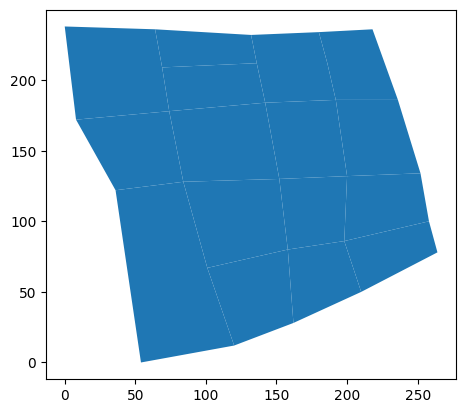

In [81]:
gdf_polygons.plot()

In [127]:
def aggregate(roads):

    roads_type = [ROAD for _ in range(len(roads))]
    intersections = []
    for road in roads:
        intersections.append(Point(road.coords[0]))
        intersections.append(Point(road.coords[1]))
    intersections = list(unary_union(intersections).geoms)
    intersections_type = [INTERSECTION for _ in range(len(intersections))]
    feasibles = list(polygonize(roads))
    feasibles_type = [FEASIBLE for _ in range(len(feasibles))]
    types = roads_type + intersections_type + feasibles_type
    geometries = roads + intersections + feasibles
    gdf = GeoDataFrame({'id': list(range(len(types))),
                        'type': types,
                        'existence': [True for _ in range(len(types))],
                        'geometry': geometries}).set_index('id')
    return gdf

In [130]:
gdf_simplified = aggregate(roads)
gdf_simplified
#plot_gdf(gdf_simplified[gdf_simplified.geom_type!='Polygon'])

,type,existence,geometry
id,,,
0,2,True,"LINESTRING (0.000 238.000, 64.000 236.000)"
1,2,True,"LINESTRING (64.000 236.000, 132.000 232.000)"
2,2,True,"LINESTRING (132.000 232.000, 180.000 234.000)"
3,2,True,"LINESTRING (180.000 234.000, 218.000 236.000)"
4,2,True,"LINESTRING (136.000 212.000, 186.000 212.000)"
...,...,...,...
91,1,True,"POLYGON ((152.000 130.000, 200.000 132.000, 19..."
92,1,True,"POLYGON ((200.000 132.000, 252.000 134.000, 25..."
93,1,True,"POLYGON ((101.000 67.000, 158.000 80.000, 162...."


In [136]:
gdf_simplified.to_file('hz_simplified.geojson', driver='GeoJSON')

In [131]:
print(len(gdf_simplified[gdf_simplified.geom_type=='LineString']))
print(len(gdf_simplified[gdf_simplified.geom_type=='Point']))
print(len(gdf_simplified[gdf_simplified.geom_type=='Polygon']))

47
33
16


In [155]:
import matplotlib.pyplot as plt

def plot_land_with_ids(gdf, figsize=(10, 10), alpha=0.5):
    """
    Plot land polygons and label them with IDs
    
    Args:
        gdf: GeoDataFrame containing polygons
        figsize: Tuple for figure size
        alpha: Float for transparency
    """
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot polygons
    gdf.plot(ax=ax, alpha=alpha)
    
    # Add ID labels at centroid of each polygon
    
    for idx, row in gdf.iterrows():
        print(row)
        centroid = row.geometry.centroid
        ax.annotate(text=str(row.id), 
                   xy=(centroid.x, centroid.y),
                   horizontalalignment='center',
                   verticalalignment='center')
    
    # Adjust plot
    plt.axis('equal')
    plt.grid(True)
    plt.show()
    
    return fig, ax

In [ ]:
gdf_land_simplified = gdf_simplified[gdf_simplified.geom_type=='Polygon']
gdf_land_simplified

<Axes: >

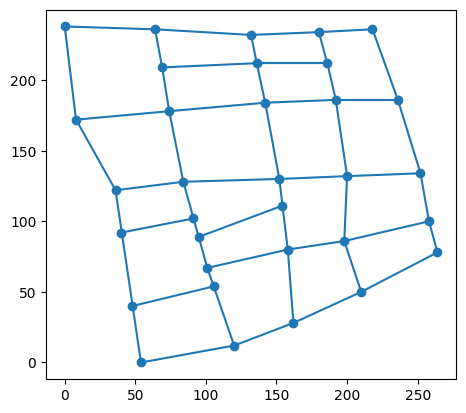

In [135]:
gdf_road_simplified = gdf_simplified[gdf_simplified.geom_type!='Polygon']
gdf_road_simplified.plot()

## compare simplified and original roads

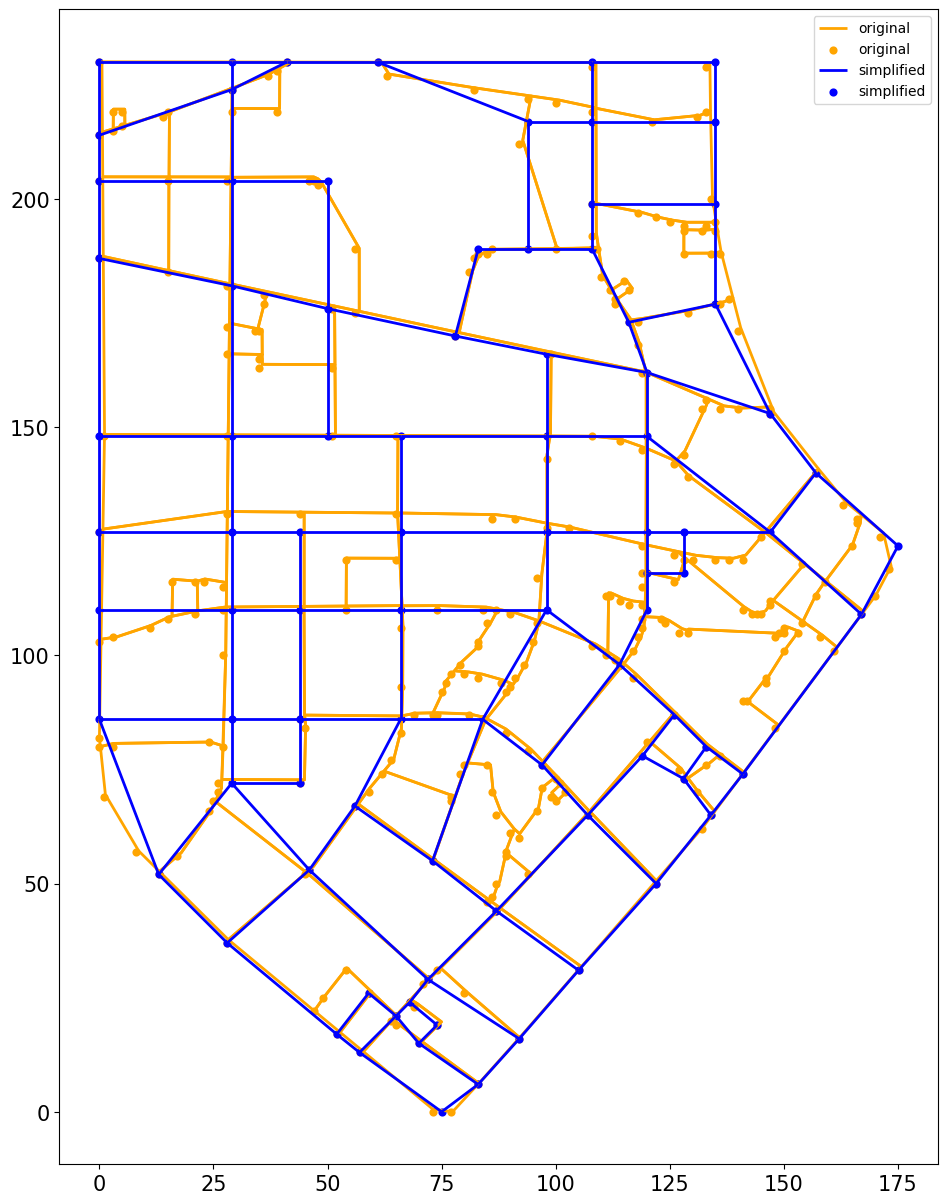

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(15,15))
gdf_road_exploded.plot(ax=ax, linewidth=2, markersize=15, color='orange', label='original')
gdf_road_simplified.plot(ax=ax, linewidth=2, markersize=15, color='blue', label='simplified')
ax.tick_params(axis='both', which='major', labelsize=15)
plt.legend()
plt.show()

## initial land use conditions

In [5]:
import geopandas as gpd
import matplotlib.pyplot as plt
my_colors = {
    3: 'lightgreen',
    5: '#e6005c',   # pink
    1: 'white',
    7: '#00ff00',
    10: '#ff7f7e',    # light red
    11: 'darkred',
    6: '#ff0000',    # red 'business_h'
    0: 'black',      # 'outside'
    4: '#ffff2d',  # yellow residential
    8: '#ffd380',   # light yellow  residential_h
    2: '#a3a3a3',      # grey
    9: '#ff85c9',   # light pink  school
    12: '#acffcf'   # light blue    recreation

    """
    1: (172, 255, 207),    # 广场用地	G3
    2: (0, 255, 0),        # 公园绿地 G
    3: (255, 211, 128),    # 居住用地（高层） Rh
    4: (255, 255, 45),     # 居住用地（多层） Rl
    5: (230, 0, 92),       # 商业服务业用地（低容积率） Bl
    6: (255, 0, 0),        # 商业服务业（高容积率） Bh
    7: (255, 127, 126),    # 医疗卫生用地 A5
    8: (255, 127, 0),      # 文化用地 A2
    9: (255, 133, 201),    # 教育用地 A3
    10: (0, 99, 128),      # 公共设施用地 U1
    11: (163, 163, 163),    # 道路用地
    12: (0, 0, 0),         # 矩形
    13: (255, 255, 255)    # 点
    """
}

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def plot_gdf_with_color(gdf, rgb_colors=None, figsize=(10, 10), alpha=0.7, labels=None):
    """
    Plot GeoDataFrame with RGB colors and legend
    
    Args:
        gdf: GeoDataFrame to plot
        rgb_colors: Dict of type_id: (r,g,b) where r,g,b are 0-255
        figsize: Tuple for figure size
        alpha: Float for transparency
        labels: Dict of type_id: label_name for legend. If None, type_id will be used as label
    """
    if rgb_colors is None:
        # Default colors as example
        rgb_colors = my_colors
    
    # Convert RGB (0-255) to matplotlib format (0-1)
    color_map = rgb_colors
    
    if labels is None:
        labels = {k: f'Type {k}' for k in rgb_colors.keys()}
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create legend elements
    legend_elements = []
    
    # Plot each type with its color
    for type_id, color in color_map.items():
        mask = gdf['type'] == type_id
        if mask.any():
            gdf[mask].plot(
                ax=ax,
                color=color,
                alpha=alpha
            )
            # Create patch for legend
            legend_elements.append(
                Patch(facecolor=color, 
                      alpha=alpha,
                      label=labels[type_id])
            )
    
    # Add legend with custom patches
    ax.legend(handles=legend_elements,bbox_to_anchor=(1.8, 1))
    
    
    # Adjust plot
    plt.axis('equal')
    plt.grid(True)
    plt.show()
    
    return fig, ax

In [4]:
gdf_simplified = gpd.read_file('hz_simplified2.geojson')
gdf_simplified.crs = None

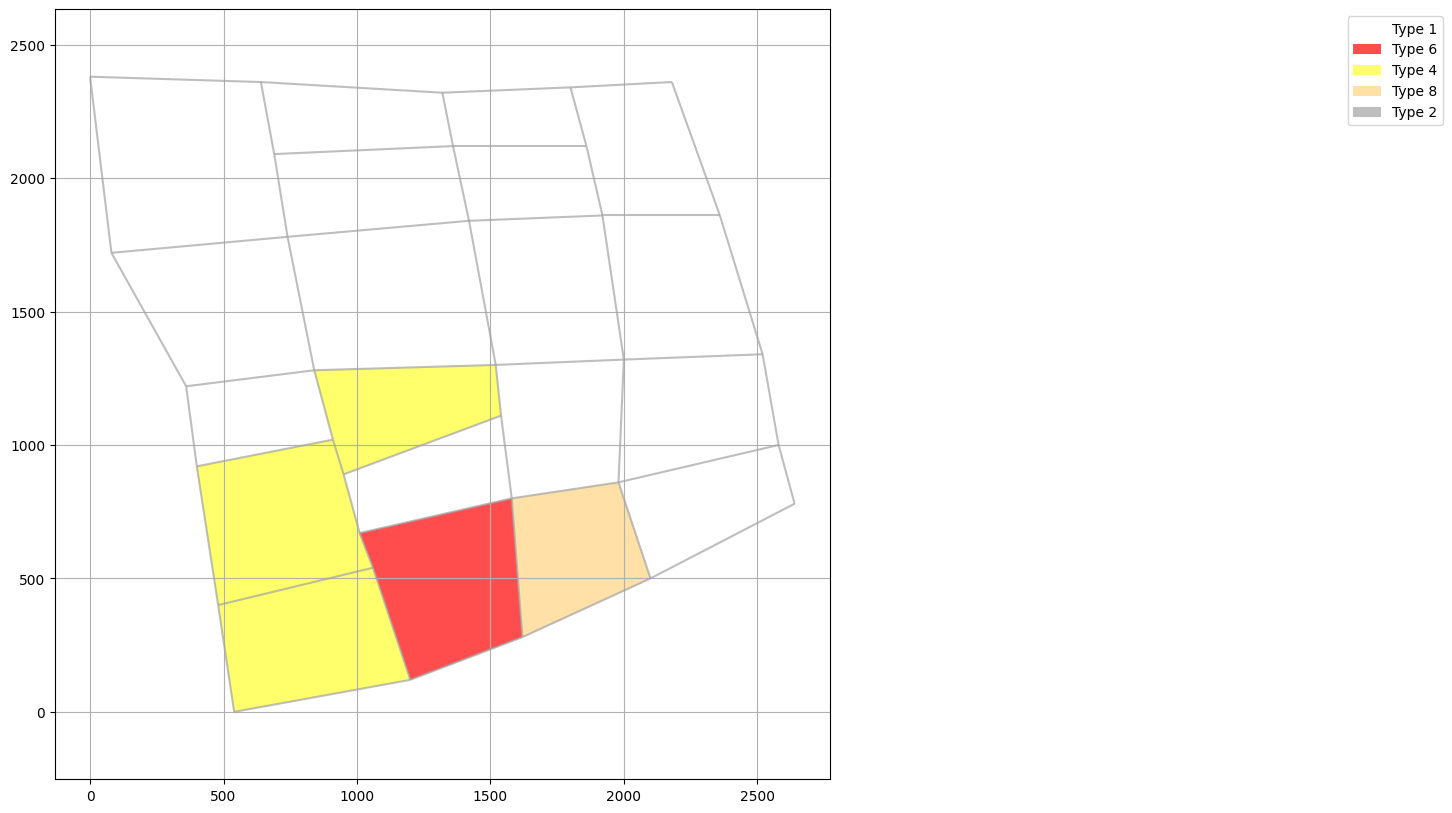

(<Figure size 1000x1000 with 1 Axes>, <Axes: >)

In [8]:
plot_gdf_with_color(gdf_simplified, rgb_colors=my_colors)


In [9]:
print(gdf_simplified.area.sum())
print(gdf_simplified.unary_union.bounds)

4539200.0
(0.0, 0.0, 2640.0, 2380.0)


## visualize

In [19]:
d = dict()
d['gdf'] = gdf_simplified
with open('./init_plan_hz.pickle', 'wb') as f:
    pickle.dump(d, f)